## Task 3 — Neural Network Classifier (CIFAR-10)

In [ ]:
# If running on Google Colab, uncomment the next line to ensure PyTorch + torchvision are available.
#!pip -q install torch torchvision --upgrade

import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 1. Load CIFAR-10 and Preprocess (Flatten + Normalize)

I loaded CIFAR-10 using torchvision and normalized pixel intensities to [0,1] via `ToTensor()`.

The DataLoader provides 4D tensors of shape (batch_size, 3, 32, 32). Flattening is not performed during preprocessing; instead, it occurs inside the model’s forward pass. This ensures the network operates purely as a fully connected MLP while still receiving properly normalized inputs.

In [ ]:
BATCH_SIZE = 128
VAL_FRACTION = 0.1

# ToTensor() maps pixels to [0, 1]. I do NOT apply extra normalization (like mean/std),
# because the prompt explicitly asks for [0, 1].
transform = transforms.ToTensor()

train_full = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_set   = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Train/val split
n_total = len(train_full)
n_val = int(n_total * VAL_FRACTION)
n_train = n_total - n_val
train_set, val_set = random_split(train_full, [n_train, n_val], generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Train:", len(train_set), "Val:", len(val_set), "Test:", len(test_set))

# Quick sanity check: shapes and range
images, labels = next(iter(train_loader))
print("Batch image tensor shape:", images.shape)  # (B, 3, 32, 32)
print("Batch label shape:", labels.shape)
print("Pixel range (min, max):", float(images.min()), float(images.max()))
print("Example labels:", labels[:10].tolist())

100%|██████████| 170M/170M [00:03<00:00, 49.8MB/s]


Train: 45000 Val: 5000 Test: 10000
Batch image tensor shape: torch.Size([128, 3, 32, 32])
Batch label shape: torch.Size([128])
Pixel range (min, max): 0.0 1.0
Example labels: [3, 6, 1, 5, 6, 1, 9, 6, 3, 4]


### 1.1 Missing value check

In [ ]:
# CIFAR-10 has no missing values by construction, but we verify explicitly.
images, _ = next(iter(train_loader))
nan_count = int(torch.isnan(images).sum().item())
inf_count = int(torch.isinf(images).sum().item())
print(f"NaN pixels in batch : {nan_count}")
print(f"Inf pixels in batch : {inf_count}")
assert nan_count == 0 and inf_count == 0, "Unexpected missing values found!"
print("Missing value check : PASSED — no NaN or Inf in image tensors.")

NaN pixels in batch : 0
Inf pixels in batch : 0
Missing value check : PASSED — no NaN or Inf in image tensors.


## 2. Define a Flexible MLP

I implemented a flexible multilayer perceptron (MLP) architecture that allows variation in:

- Number of hidden layers  
- Number of neurons per layer  
- Optional dropout regularization  

The architecture enforces the assignment constraints (at most 8 hidden layers and 1000 neurons per layer). Hidden layers use ReLU activation, and the output layer produces logits for multi-class classification. Cross-Entropy Loss is used, which internally applies softmax.

In [ ]:
INPUT_DIM = 3 * 32 * 32
NUM_CLASSES = 10

class MLPClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_layers: int, hidden_units: int,
                 activation: str = "relu", dropout: float = 0.0, num_classes: int = 10):
        super().__init__()
        assert 1 <= hidden_layers <= 8, "Do not exceed 8 hidden layers."
        assert 1 <= hidden_units <= 1000, "Do not exceed 1000 neurons per hidden layer."
        assert activation in {"relu", "sigmoid", "tanh"}, "Supported activations: relu/sigmoid/tanh"

        self.activation_name = activation
        self.dropout_p = dropout

        layers = []
        in_dim = input_dim
        for _ in range(hidden_layers):
            layers.append(nn.Linear(in_dim, hidden_units))
            if activation == "relu":
                layers.append(nn.ReLU())
            elif activation == "sigmoid":
                layers.append(nn.Sigmoid())
            else:
                layers.append(nn.Tanh())

            if dropout and dropout > 0:
                layers.append(nn.Dropout(p=dropout))

            in_dim = hidden_units

        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

tmp_model = MLPClassifier(INPUT_DIM, hidden_layers=2, hidden_units=128, activation="relu", dropout=0.25).to(device)
tmp_x, _ = next(iter(train_loader))
tmp_out = tmp_model(tmp_x.to(device))
print("Output logits shape:", tmp_out.shape)

Output logits shape: torch.Size([128, 10])


## 3. Training and Evaluation Utilities

I implemented reusable training and evaluation routines to compute cross-entropy loss and classification accuracy for both training and validation sets. These utilities allow consistent comparison across architectures and regularization strategies.

In [ ]:
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return float((preds == y).float().mean().item())

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for X, y in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(X)
        loss = criterion(logits, y)

        total_loss += float(loss.item()) * y.size(0)
        total_correct += int((logits.argmax(dim=1) == y).sum().item())
        total += y.size(0)

    return total_loss / total, total_correct / total

def train_model(model, train_loader, val_loader, epochs=15, lr=1e-3, weight_decay=0.0):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        total = 0

        for X, y in train_loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += float(loss.item()) * y.size(0)
            running_correct += int((logits.argmax(dim=1) == y).sum().item())
            total += y.size(0)

        train_loss = running_loss / total
        train_acc = running_correct / total

        val_loss, val_acc = eval_epoch(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    elapsed = time.time() - t0
    return history, elapsed

## 4. Task 3a — Effect of Model Capacity

To analyze the impact of model capacity, I compared multiple architectural patterns:

- Shallow-wide (e.g., 2×512)
- Shallow-narrow (e.g., 2×128)
- Deep-narrow (e.g., 6×128, 8×128)
- Deep-medium (e.g., 6×256)

Optimizer, learning rate, batch size, and number of epochs were kept fixed to ensure a fair comparison.

Results show that shallow-wide architectures achieved the best validation performance. Increasing depth did not improve accuracy and often slowed convergence. Since flattened pixel inputs do not preserve spatial structure, additional depth does not provide hierarchical feature extraction benefits as it would in convolutional architectures.

In [ ]:
EPOCHS_EXP = 20   # increase in Colab if you have time (e.g., 15–25)
LR = 1e-3

arch_grid = [
    {"name": "shallow-wide", "hidden_layers": 2, "hidden_units": 512, "dropout": 0.0, "weight_decay": 0.0},
    {"name": "shallow-narrow", "hidden_layers": 2, "hidden_units": 128, "dropout": 0.0, "weight_decay": 0.0},
    {"name": "deep-narrow", "hidden_layers": 6, "hidden_units": 128, "dropout": 0.0, "weight_decay": 0.0},
    {"name": "deep-medium", "hidden_layers": 6, "hidden_units": 256, "dropout": 0.0, "weight_decay": 0.0},
    {"name": "very-deep-narrow", "hidden_layers": 8, "hidden_units": 128, "dropout": 0.0, "weight_decay": 0.0},
]

results_a = []

for cfg in arch_grid:
    print(f"\n===== Experiment: {cfg['name']} (L={cfg['hidden_layers']}, H={cfg['hidden_units']}) =====")
    model = MLPClassifier(INPUT_DIM,
                          hidden_layers=cfg["hidden_layers"],
                          hidden_units=cfg["hidden_units"],
                          activation="relu",
                          dropout=cfg["dropout"]).to(device)

    history, elapsed = train_model(
        model, train_loader, val_loader,
        epochs=EPOCHS_EXP, lr=LR, weight_decay=cfg["weight_decay"]
    )

    best_val_acc = max(history["val_acc"])
    best_val_loss = min(history["val_loss"])
    gap = (history["val_loss"][-1] - history["train_loss"][-1])  # positive = overfitting

    results_a.append({
        "name": cfg["name"],
        "hidden_layers": cfg["hidden_layers"],
        "hidden_units": cfg["hidden_units"],
        "dropout": cfg["dropout"],
        "weight_decay": cfg["weight_decay"],
        "time_sec": elapsed,
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "final_train_loss": history["train_loss"][-1],
        "final_val_loss": history["val_loss"][-1],
        "train_val_loss_gap": gap,
        "history": history,
        "model_state": model.state_dict(),  # save best later if needed
    })

import pandas as pd
df_a = pd.DataFrame([{k:v for k,v in r.items() if k not in ["history","model_state"]} for r in results_a])
df_a = df_a.sort_values("best_val_acc", ascending=False)
display(df_a)


===== Experiment: shallow-wide (L=2, H=512) =====
Epoch 01/20 | train_loss=1.8514 train_acc=0.3285 | val_loss=1.7178 val_acc=0.3722
Epoch 02/20 | train_loss=1.6641 train_acc=0.4058 | val_loss=1.6931 val_acc=0.3922
Epoch 03/20 | train_loss=1.5842 train_acc=0.4326 | val_loss=1.5522 val_acc=0.4438
Epoch 04/20 | train_loss=1.5246 train_acc=0.4546 | val_loss=1.5583 val_acc=0.4476
Epoch 05/20 | train_loss=1.4841 train_acc=0.4686 | val_loss=1.5463 val_acc=0.4540
Epoch 06/20 | train_loss=1.4409 train_acc=0.4846 | val_loss=1.4527 val_acc=0.4822
Epoch 07/20 | train_loss=1.4089 train_acc=0.4984 | val_loss=1.4740 val_acc=0.4710
Epoch 08/20 | train_loss=1.3741 train_acc=0.5079 | val_loss=1.4263 val_acc=0.5006
Epoch 09/20 | train_loss=1.3457 train_acc=0.5222 | val_loss=1.4145 val_acc=0.5058
Epoch 10/20 | train_loss=1.3192 train_acc=0.5296 | val_loss=1.4392 val_acc=0.4906
Epoch 11/20 | train_loss=1.2930 train_acc=0.5382 | val_loss=1.4505 val_acc=0.4890
Epoch 12/20 | train_loss=1.2636 train_acc=0.549

,name,hidden_layers,hidden_units,dropout,weight_decay,time_sec,best_val_acc,best_val_loss,final_train_loss,final_val_loss,train_val_loss_gap
0,shallow-wide,2,512,0.0,0.0,151.100290,0.5152,1.392942,1.086351,1.426683,0.340332
2,deep-narrow,6,128,0.0,0.0,151.134698,0.5010,1.424539,1.250789,1.431658,0.180869
3,deep-medium,6,256,0.0,0.0,151.191247,0.5010,1.439602,1.164100,1.470127,0.306027
1,shallow-narrow,2,128,0.0,0.0,145.535663,0.4938,1.425987,1.251331,1.440409,0.189078
4,very-deep-narrow,8,128,0.0,0.0,153.034101,0.4736,1.479389,1.319411,1.527075,0.207664


### 4.1 Visualize convergence (loss/accuracy curves)

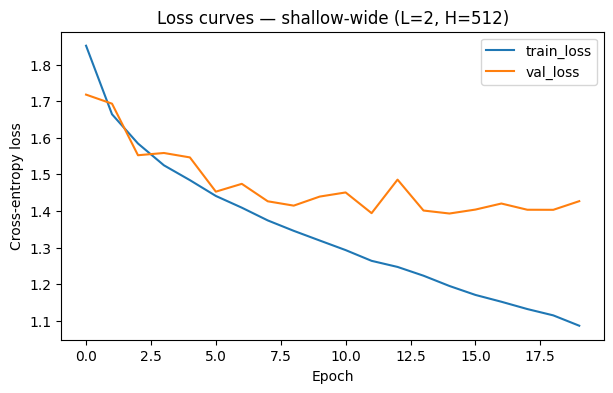

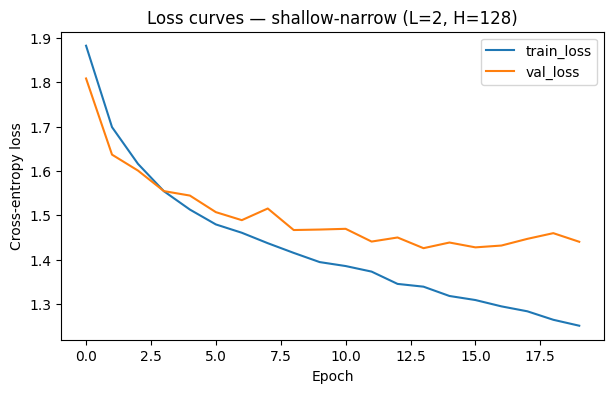

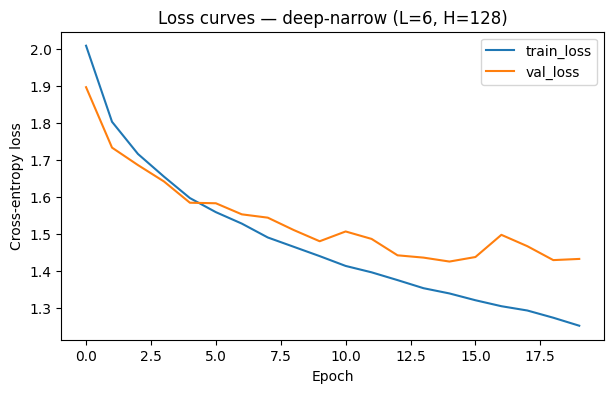

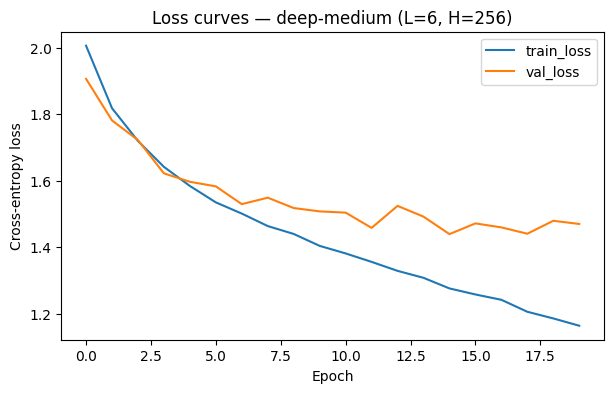

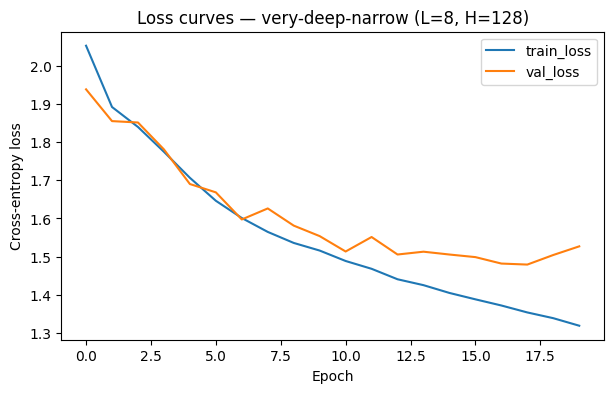

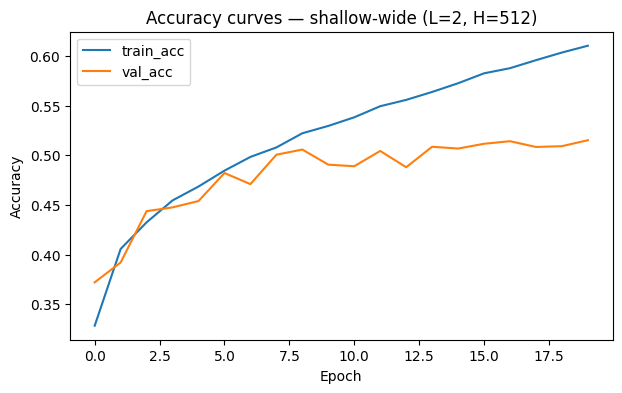

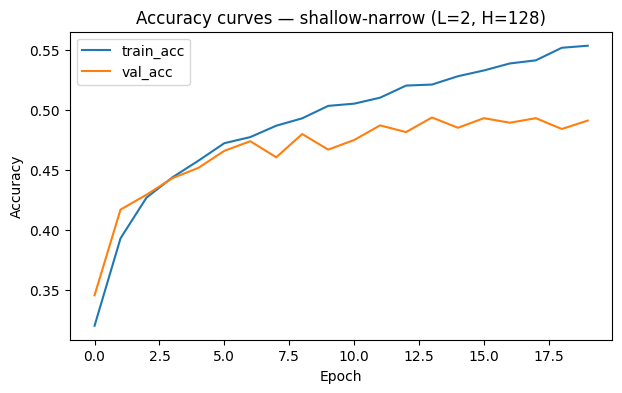

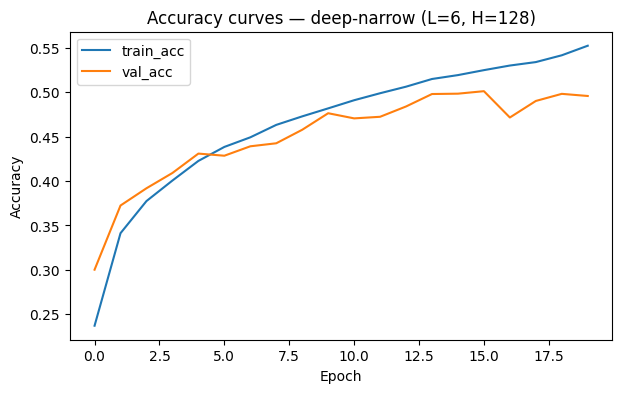

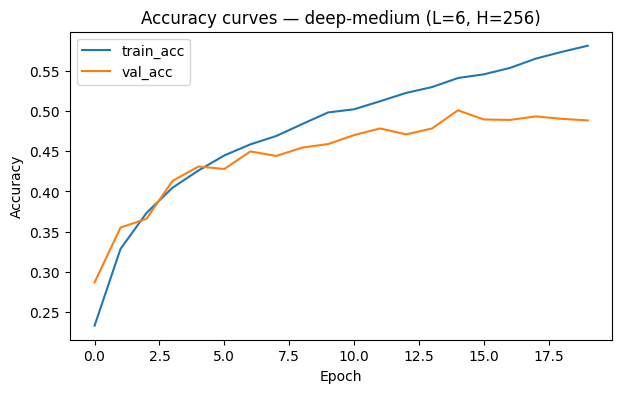

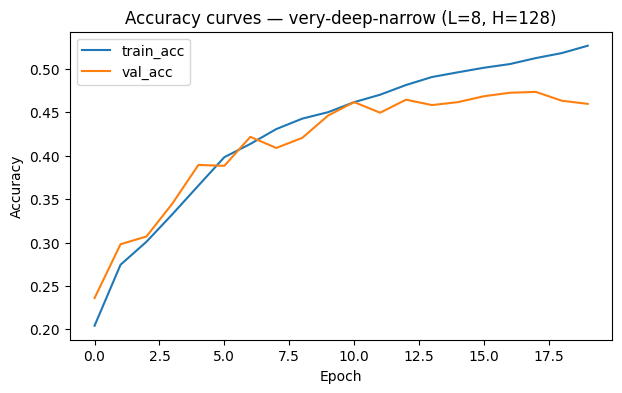

In [ ]:
for r in results_a:
    h = r["history"]
    plt.figure(figsize=(7,4))
    plt.plot(h["train_loss"], label="train_loss")
    plt.plot(h["val_loss"], label="val_loss")
    plt.title(f"Loss curves — {r['name']} (L={r['hidden_layers']}, H={r['hidden_units']})")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.legend()
    plt.show()

for r in results_a:
    h = r["history"]
    plt.figure(figsize=(7,4))
    plt.plot(h["train_acc"], label="train_acc")
    plt.plot(h["val_acc"], label="val_acc")
    plt.title(f"Accuracy curves — {r['name']} (L={r['hidden_layers']}, H={r['hidden_units']})")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

## 5. Task 3b — Regularization

To mitigate overfitting, I evaluated two regularization techniques:

- Dropout (p = 0.3 and p = 0.5)
- L2 regularization (weight decay = 1e-4)

For each configuration, I monitored the train–validation loss gap (validation loss minus training loss).

L2 regularization provided the most stable validation performance and reduced the train–validation gap while preserving accuracy. Moderate dropout reduced overfitting; in particular, dropout=0.3 produced a near-zero (slightly negative) gap, suggesting mild underfitting or stochastic regularization effects. Higher dropout rates further reduced overfitting but also degraded overall accuracy, likely because aggressive dropout limits effective capacity in an already capacity-limited MLP operating on flattened pixel features.

In [ ]:
import copy

base_cfg = {"hidden_layers": int(df_a.iloc[0]["hidden_layers"]), "hidden_units": int(df_a.iloc[0]["hidden_units"])}
EPOCHS_REG = 25

reg_experiments = [
    {"name": "no_reg",       "dropout": 0.0, "weight_decay": 0.0},
    {"name": "dropout_0.3",  "dropout": 0.3, "weight_decay": 0.0},
    {"name": "dropout_0.5",  "dropout": 0.5, "weight_decay": 0.0},
    {"name": "l2_wd_1e-4",   "dropout": 0.0, "weight_decay": 1e-4},
]

results_b = []


for exp in reg_experiments:
    print(f"\n===== Regularization experiment: {exp['name']} (dropout={exp['dropout']}) =====")
    model = MLPClassifier(INPUT_DIM,
                          hidden_layers=base_cfg["hidden_layers"],
                          hidden_units=base_cfg["hidden_units"],
                          activation="relu",
                          dropout=exp["dropout"]).to(device)

    history, elapsed = train_model(model, train_loader, val_loader, epochs=EPOCHS_REG, lr=LR, weight_decay=exp["weight_decay"])

    results_b.append({
        "name": exp["name"],
        "dropout": exp["dropout"],
        "weight_decay": exp.get("weight_decay", 0.0),
        "time_sec": elapsed,
        "final_train_loss": history["train_loss"][-1],
        "final_val_loss": history["val_loss"][-1],
        "train_val_loss_gap": history["val_loss"][-1] - history["train_loss"][-1],
        "best_val_acc": max(history["val_acc"]),
        "history": history,
        "model_state": copy.deepcopy(model.state_dict()),
    })

df_b = pd.DataFrame([{k:v for k,v in r.items() if k not in ["history","model"]} for r in results_b])
display(df_b)


===== Regularization experiment: no_reg (dropout=0.0) =====
Epoch 01/25 | train_loss=1.8644 train_acc=0.3226 | val_loss=1.7367 val_acc=0.3784
Epoch 02/25 | train_loss=1.6646 train_acc=0.4055 | val_loss=1.6327 val_acc=0.4124
Epoch 03/25 | train_loss=1.5842 train_acc=0.4339 | val_loss=1.5579 val_acc=0.4548
Epoch 04/25 | train_loss=1.5298 train_acc=0.4541 | val_loss=1.5482 val_acc=0.4486
Epoch 05/25 | train_loss=1.4787 train_acc=0.4733 | val_loss=1.5122 val_acc=0.4604
Epoch 06/25 | train_loss=1.4431 train_acc=0.4844 | val_loss=1.4919 val_acc=0.4702
Epoch 07/25 | train_loss=1.4154 train_acc=0.4948 | val_loss=1.4716 val_acc=0.4808
Epoch 08/25 | train_loss=1.3752 train_acc=0.5110 | val_loss=1.4608 val_acc=0.4776
Epoch 09/25 | train_loss=1.3539 train_acc=0.5191 | val_loss=1.4521 val_acc=0.4808
Epoch 10/25 | train_loss=1.3303 train_acc=0.5258 | val_loss=1.4300 val_acc=0.4948
Epoch 11/25 | train_loss=1.2978 train_acc=0.5366 | val_loss=1.4197 val_acc=0.4914
Epoch 12/25 | train_loss=1.2740 train

,name,dropout,weight_decay,time_sec,final_train_loss,final_val_loss,train_val_loss_gap,best_val_acc,model_state
0,no_reg,0.0,0.0000,185.985776,1.019539,1.430041,0.410502,0.5268,"{'net.0.weight': [[tensor(0.0255, device='cuda..."
1,dropout_0.3,0.3,0.0000,185.569312,1.537281,1.531830,-0.005451,0.4696,"{'net.0.weight': [[tensor(-0.0198, device='cud..."
2,dropout_0.5,0.5,0.0000,185.987225,1.770410,1.795582,0.025172,0.4078,"{'net.0.weight': [[tensor(-0.0201, device='cud..."
3,l2_wd_1e-4,0.0,0.0001,185.029209,1.037353,1.402742,0.365389,0.5332,"{'net.0.weight': [[tensor(-1.8377e-20, device=..."


### 5.1 Regularization effect on the train–validation gap

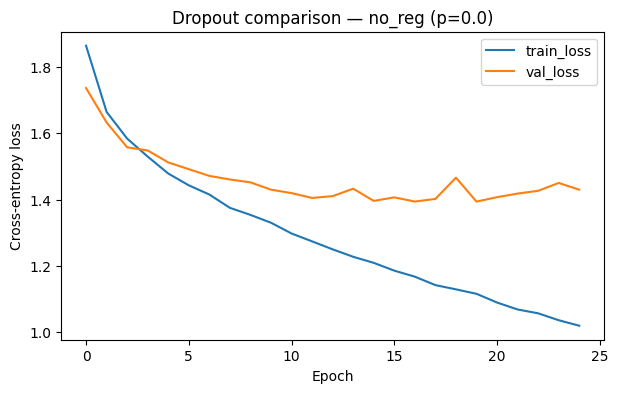

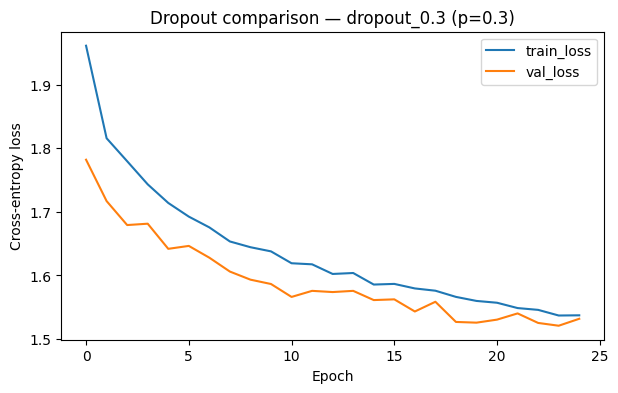

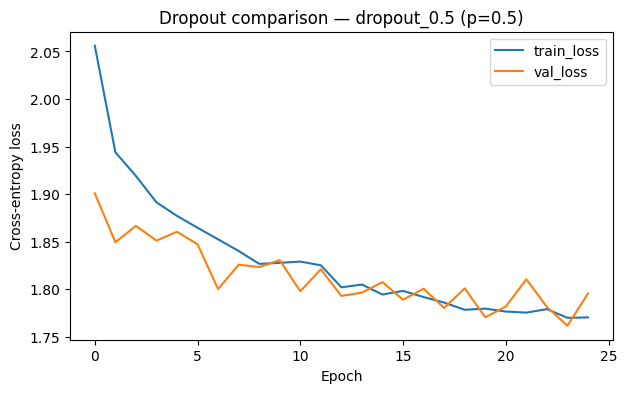

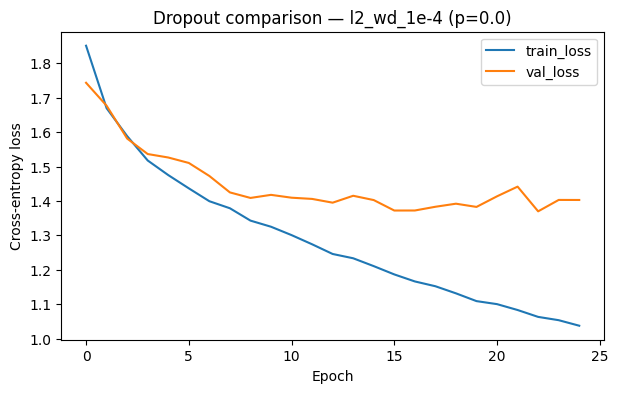

In [9]:
for r in results_b:
    h = r["history"]
    plt.figure(figsize=(7,4))
    plt.plot(h["train_loss"], label="train_loss")
    plt.plot(h["val_loss"], label="val_loss")
    plt.title(f"Dropout comparison — {r['name']} (p={r['dropout']})")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.legend()
    plt.show()

## 6. Select the Best Model

I selected the best-performing regularized configuration based on validation accuracy and validation loss. Only models including regularization were considered for final evaluation to ensure balanced generalization performance.

In [ ]:
regularized = [r for r in results_b if (r.get("dropout", 0.0) > 0) or (r.get("weight_decay", 0.0) > 0)]

if len(regularized) == 0:
    print("WARNING: No regularized models found; falling back to overall best.")
    candidates = results_b
else:
    candidates = regularized

best = sorted(candidates, key=lambda r: (-r["best_val_acc"], r["final_val_loss"]))[0]

best["weight_decay"] = float(best.get("weight_decay", 0.0))
best["dropout"]      = float(best.get("dropout", 0.0))

print(f"Selected model: {best['name']} | dropout={best['dropout']} | weight_decay={best['weight_decay']}")
print(f"Best val_acc: {best['best_val_acc']:.4f}")

best_model = MLPClassifier(
    INPUT_DIM,
    hidden_layers=base_cfg["hidden_layers"],
    hidden_units=base_cfg["hidden_units"],
    activation="relu",
    dropout=best["dropout"],
).to(device)

if "model_state" in best and best["model_state"] is not None:
    best_model.load_state_dict(best["model_state"])
    print("Loaded saved weights from the sweep (model_state).")
else:
    print("No model_state found in results_b → training final model from scratch.")

EPOCHS_FINAL = 35
LR_FINAL     = 5e-4

print(f"\n=== FINAL FIT (finetune) ===")
history_final, elapsed_final = train_model(
    best_model, train_loader, val_loader,
    epochs=EPOCHS_FINAL, lr=LR_FINAL, weight_decay=best["weight_decay"]
)

print(f"\nFinal fit done. Total time: {elapsed_final:.1f}s")
print(f"Best val_acc (finetune): {max(history_final['val_acc']):.4f} | Best val_loss (finetune): {min(history_final['val_loss']):.4f}")

Selected model: l2_wd_1e-4 | dropout=0.0 | weight_decay=0.0001
Best val_acc: 0.5332
Loaded saved weights from the sweep (model_state).

=== FINAL FIT (finetune) ===
Epoch 01/35 | train_loss=0.9461 train_acc=0.6639 | val_loss=1.3747 val_acc=0.5318
Epoch 02/35 | train_loss=0.9213 train_acc=0.6748 | val_loss=1.3621 val_acc=0.5326
Epoch 03/35 | train_loss=0.8994 train_acc=0.6838 | val_loss=1.3766 val_acc=0.5458
Epoch 04/35 | train_loss=0.8911 train_acc=0.6853 | val_loss=1.3898 val_acc=0.5412
Epoch 05/35 | train_loss=0.8780 train_acc=0.6902 | val_loss=1.4231 val_acc=0.5378
Epoch 06/35 | train_loss=0.8664 train_acc=0.6944 | val_loss=1.3947 val_acc=0.5424
Epoch 07/35 | train_loss=0.8551 train_acc=0.6982 | val_loss=1.4002 val_acc=0.5458
Epoch 08/35 | train_loss=0.8427 train_acc=0.7035 | val_loss=1.4312 val_acc=0.5306
Epoch 09/35 | train_loss=0.8324 train_acc=0.7075 | val_loss=1.4309 val_acc=0.5326
Epoch 10/35 | train_loss=0.8206 train_acc=0.7094 | val_loss=1.4632 val_acc=0.5376
Epoch 11/35 | t

## 7. Task 3c — Final Evaluation on Test Set

The selected regularized model was evaluated on the held-out test set. I report overall classification accuracy, cross-entropy loss, and the confusion matrix.

The confusion matrix reveals systematic misclassification between visually similar animal categories, particularly dog and cat. Classes with distinctive global shapes, such as ship and frog, achieved higher accuracy, while cat was among the hardest classes.

Overall performance is consistent with the expected ceiling for fully connected networks applied to CIFAR-10. Flattening images destroys spatial relationships between neighboring pixels, preventing the model from learning local edge patterns or hierarchical visual features. Convolutional Neural Networks (CNNs), which preserve spatial structure, typically achieve substantially higher accuracy on this dataset. Therefore, the primary limitation observed here is architectural rather than due to hyperparameter choices.

In [11]:
criterion = nn.CrossEntropyLoss()

test_loss, test_acc = eval_epoch(best_model, test_loader, criterion)
print(f"Test cross-entropy loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test cross-entropy loss: 1.7004
Test accuracy: 0.5243


<Figure size 900x900 with 0 Axes>

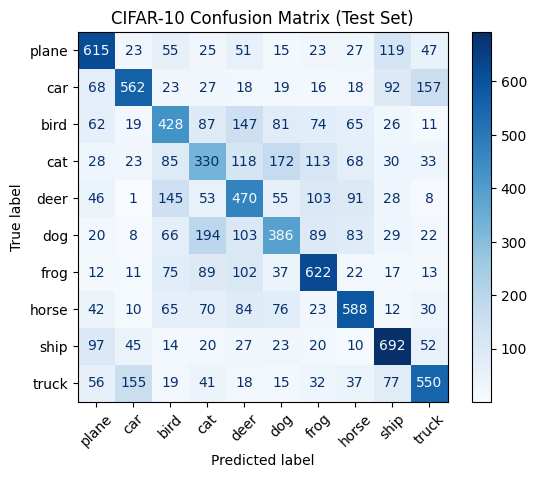

Most confused pair: true='dog' predicted='cat' | count=194


In [ ]:
best_model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device, non_blocking=True)
        logits = best_model(X)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_true.append(y.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_true)

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

plt.figure(figsize=(9,9))
disp.plot(xticks_rotation=45, cmap=plt.cm.Blues, colorbar=True)
plt.title("CIFAR-10 Confusion Matrix (Test Set)")
plt.show()

# Most confused pairs (off-diagonal largest)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
i, j = np.unravel_index(cm_off.argmax(), cm_off.shape)
print(f"Most confused pair: true='{classes[i]}' predicted='{classes[j]}' | count={cm_off[i,j]}")